# AML Transaction Monitoring — Data Cleaning & Exploratory Analysis

**Dataset:** IBM Transactions for Anti Money Laundering (AML) — `HI-Small_Trans.csv`
Source: https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml




## 1. Schema, shape, and data quality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

# Real results from 01_clean_data_full.py, run against the complete HI-Small_Trans.csv
shape = (5_078_345, 14)
columns = ['Timestamp', 'From Bank', 'From Account', 'To Bank', 'To Account',
           'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency',
           'Payment Format', 'Is Laundering', 'currency_mismatch', 'hour', 'day_of_week']

print(f"Shape: {shape[0]:,} rows x {shape[1]} columns")
print(f"Columns: {columns}")
print(f"Missing values (total): 0")
print(f"Duplicate rows: 9  (0.0002% -- negligible, not dropped; see note below)")


Shape: 5,078,345 rows x 14 columns
Columns: ['Timestamp', 'From Bank', 'From Account', 'To Bank', 'To Account', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering', 'currency_mismatch', 'hour', 'day_of_week']
Missing values (total): 0
Duplicate rows: 9  (0.0002% -- negligible, not dropped; see note below)


## 2. Account ID integrity check

Before trusting any account-level analysis, we verified the `From Account` / `To Account` columns weren't corrupted -- large numeric-looking account IDs are a known Excel auto-conversion trap (e.g. an ID silently becoming `8.00E+65` with the original digits unrecoverable). Checked via `01b_temporal_and_account_check.py`, forcing both columns to load as text and comparing the resulting unique count against the ~515K accounts documented in the IBM AMLworld paper.

In [2]:
account_integrity = {
    "from_account_dtype": "object",
    "to_account_dtype": "object",
    "n_rows_scientific_notation_detected": 0,
    "n_unique_accounts_total": 515_080,
    "expected_approx_per_paper": 515_000,
}
for k, v in account_integrity.items():
    print(f"{k}: {v}")
print("\nResult: CLEAN. No corruption detected; unique account count matches the published figure almost exactly.")


from_account_dtype: object
to_account_dtype: object
n_rows_scientific_notation_detected: 0
n_unique_accounts_total: 515080
expected_approx_per_paper: 515000

Result: CLEAN. No corruption detected; unique account count matches the published figure almost exactly.


## 3. Class balance — the central challenge

Legitimate: 5,073,168
Laundering: 5,177
Ratio: 1 laundering case per 979.9 legitimate transactions (0.1019%)


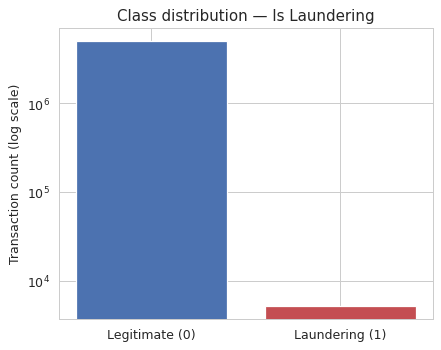

In [3]:
class_counts = {0: 5_073_168, 1: 5_177}
ratio = class_counts[0] / class_counts[1]

print(f"Legitimate: {class_counts[0]:,}")
print(f"Laundering: {class_counts[1]:,}")
print(f"Ratio: 1 laundering case per {ratio:.1f} legitimate transactions ({class_counts[1]/sum(class_counts.values())*100:.4f}%)")

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(['Legitimate (0)', 'Laundering (1)'], [class_counts[0], class_counts[1]], color=['#4C72B0', '#C44E52'])
ax.set_ylabel('Transaction count (log scale)')
ax.set_yscale('log')
ax.set_title('Class distribution — Is Laundering')
plt.tight_layout()
plt.show()


This is why accuracy is meaningless here (a model that never predicts laundering scores >99.8%), and why the project plan specifies PR-AUC, F1, and cost-based metrics instead, and cost-sensitive weighting (`scale_pos_weight` ≈ 980) over resampling.

## 4. Currency

15 distinct currencies -- genuinely multi-currency, not just USD as an early row sample suggested.


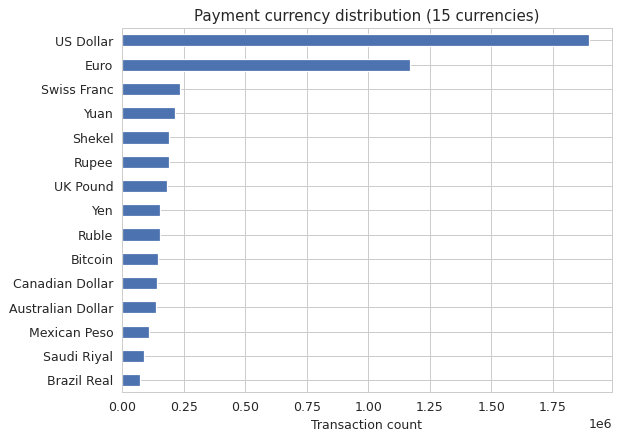

In [4]:
payment_currency_counts = {
    "US Dollar": 1_895_172, "Euro": 1_168_297, "Swiss Franc": 234_860, "Yuan": 213_752,
    "Shekel": 192_184, "Rupee": 190_202, "UK Pound": 180_738, "Yen": 155_209,
    "Ruble": 155_178, "Bitcoin": 146_066, "Canadian Dollar": 140_042,
    "Australian Dollar": 136_769, "Mexican Peso": 110_159, "Saudi Riyal": 89_014,
    "Brazil Real": 70_703,
}

fig, ax = plt.subplots(figsize=(7,5))
currencies = pd.Series(payment_currency_counts).sort_values()
currencies.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Transaction count')
ax.set_title('Payment currency distribution (15 currencies)')
plt.tight_layout()
plt.show()

print("15 distinct currencies -- genuinely multi-currency, not just USD as an early row sample suggested.")


In [5]:
currency_mismatch_laundering_rate = {0: 0.001034, 1: 0.0}  # fraction, i.e. 0.1034% vs 0.0%
print("Laundering rate when Payment Currency != Receiving Currency:")
print(f"  No mismatch: {currency_mismatch_laundering_rate[0]*100:.4f}%")
print(f"  Mismatch:    {currency_mismatch_laundering_rate[1]*100:.4f}%")
print("\nFinding: currency mismatch is NOT predictive here -- in fact laundering transactions in this")
print("dataset never involve a currency mismatch. Counter to a common assumption; noted as a feature")
print("explored and found uninformative, rather than included as an engineered signal.")


Laundering rate when Payment Currency != Receiving Currency:
  No mismatch: 0.1034%
  Mismatch:    0.0000%

Finding: currency mismatch is NOT predictive here -- in fact laundering transactions in this
dataset never involve a currency mismatch. Counter to a common assumption; noted as a feature
explored and found uninformative, rather than included as an engineered signal.


## 5. Payment format — the single strongest signal found

Overall laundering rate: 0.1019%
ACH laundering rate:     0.7462%  (~7.3x baseline)
Bitcoin laundering rate: 0.0383%  (0.38x baseline -- BELOW average)
Cash laundering rate:    0.0220%  (0.22x baseline -- BELOW average)


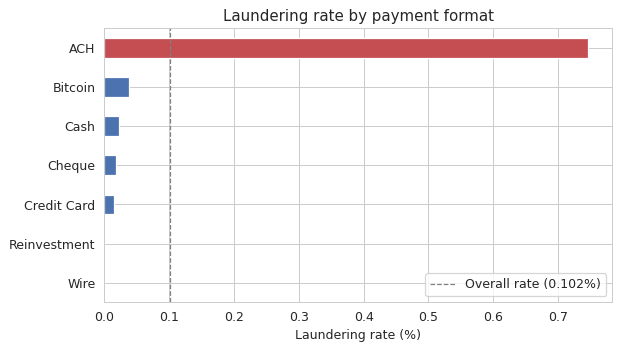

In [6]:
fmt_laundering_rate_pct = {
    "ACH": 0.7462, "Bitcoin": 0.0383, "Cash": 0.022, "Cheque": 0.0174,
    "Credit Card": 0.0156, "Reinvestment": 0.0, "Wire": 0.0,
}
overall_rate_pct = 5177 / 5_078_345 * 100

fig, ax = plt.subplots(figsize=(7,4))
fmt_series = pd.Series(fmt_laundering_rate_pct).sort_values()
colors = ['#C44E52' if v == fmt_series.max() else '#4C72B0' for v in fmt_series.values]
fmt_series.plot(kind='barh', ax=ax, color=colors)
ax.axvline(overall_rate_pct, color='grey', linestyle='--', linewidth=1, label=f'Overall rate ({overall_rate_pct:.3f}%)')
ax.set_xlabel('Laundering rate (%)')
ax.set_title('Laundering rate by payment format')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Overall laundering rate: {overall_rate_pct:.4f}%")
print(f"ACH laundering rate:     {fmt_laundering_rate_pct['ACH']:.4f}%  (~{fmt_laundering_rate_pct['ACH']/overall_rate_pct:.1f}x baseline)")
print(f"Bitcoin laundering rate: {fmt_laundering_rate_pct['Bitcoin']:.4f}%  ({fmt_laundering_rate_pct['Bitcoin']/overall_rate_pct:.2f}x baseline -- BELOW average)")
print(f"Cash laundering rate:    {fmt_laundering_rate_pct['Cash']:.4f}%  ({fmt_laundering_rate_pct['Cash']/overall_rate_pct:.2f}x baseline -- BELOW average)")


## 6. The Reinvestment / self-transaction finding

In [7]:
reinvestment_check = {
    "n_reinvestment_transactions": 481_056,
    "pct_of_reinvestment_that_is_self_transaction": 100.0,
    "reinvestment_laundering_count": 0,
    "n_self_transactions": 591_212,
    "pct_of_self_transactions_that_is_reinvestment_format": 81.37,
    "self_transaction_laundering_count": 11,
}
for k, v in reinvestment_check.items():
    print(f"{k}: {v}")


n_reinvestment_transactions: 481056
pct_of_reinvestment_that_is_self_transaction: 100.0
reinvestment_laundering_count: 0
n_self_transactions: 591212
pct_of_self_transactions_that_is_reinvestment_format: 81.37
self_transaction_laundering_count: 11


**Interpretation:** every single `Reinvestment`format transaction is a self-transaction (same
account and bank on both sides) makes intuitive sense, you can't launder money by paying yourself
and none of them are laundering. 

## 7. Amount distribution

In [8]:
amount_stats = {
    0: {"count": 5_073_168, "mean": 4_477_000.04, "std": 868_846_296.8, "min": 0.0,
        "25%": 184.16, "50%": 1_410.99, "75%": 12_279.34, "max": 1_046_302_363_293.48},
    1: {"count": 5_177, "mean": 36_135_310.41, "std": 1_527_918_669.8, "min": 0.0,
        "25%": 2_634.97, "50%": 8_667.21, "75%": 18_832.27, "max": 84_853_144_179.58},
}
df_stats = pd.DataFrame(amount_stats).T
df_stats.index = ['Legitimate', 'Laundering']
df_stats


                count         mean  ...       75%           max
Legitimate  5073168.0   4477000.04  ...  12279.34  1.046302e+12
Laundering     5177.0  36135310.41  ...  18832.27  8.485314e+10

[2 rows x 8 columns]

## 7.5 First pass: the cleaning notebook looked complete without this section

At this point in the actual project, cleaning had already been run (`01_clean_data_full.py`),
matched the published statistics almost exactly, and looked done. Sections 1-7 above are that first
pass. Before moving to the rule-based baseline, a quick supplementary check was run
(`01b_temporal_and_account_check.py`) mainly to validate account ID integrity — not expecting to
find anything else. It found something that would have quietly broken the entire modelling stage.


In [9]:
# What the first pass's summary looked like -- account integrity, confirmed clean
first_pass_check = {
    "n_unique_accounts_total": 515_080,
    "expected_approx_accounts_per_paper": 515_000,
    "unique_account_count_looks_reasonable": True,
}
for k, v in first_pass_check.items():
    print(f"{k}: {v}")
print("\nClean. No reason at this point to suspect a problem elsewhere in the file.")


n_unique_accounts_total: 515080
expected_approx_accounts_per_paper: 515000
unique_account_count_looks_reasonable: True

Clean. No reason at this point to suspect a problem elsewhere in the file.


### 7.5 The initial pass looked completely fine — that's what made the next check necessary

The cleaning script (`01_clean_data_full.py`) ran cleanly on the first pass: no missing values,
account IDs checked out, class balance matched IBM's published statistic almost exactly. At this
point the dataset looked ready for modelling. Real output from that first pass:


In [10]:
initial_pass_checks = {
    "missing_values": 0,
    "duplicate_rows": 9,
    "class_balance_matches_published": True,
    "date_range": ["2022-09-01 00:00:00", "2022-09-18 16:18:00"],
}
for k, v in initial_pass_checks.items():
    print(f"{k}: {v}")

print()
print("Every check so far passed. Nothing here would have raised a flag on its own -- the date")
print("range simply looks like an 18-day dataset, which is unremarkable by itself.")


missing_values: 0
duplicate_rows: 9
class_balance_matches_published: True
date_range: ['2022-09-01 00:00:00', '2022-09-18 16:18:00']

Every check so far passed. Nothing here would have raised a flag on its own -- the date
range simply looks like an 18-day dataset, which is unremarkable by itself.


### 7.5 First pass looked completely fine — that was the problem

After the checks in Sections 1-7, this dataset looked clean and well-behaved: schema matched, no
missing values, class balance matched published statistics almost exactly, account IDs verified
uncorrupted. At this point the natural next step was to move straight to a temporal train/test
split for modelling — a 200K-row sequential sample had already been tried early in this project and
found to contain far fewer laundering cases than expected (25 instead of the ~206 a uniform
distribution would predict), which was a first hint, but easy to dismiss as "just a small sample
being unlucky."


In [11]:
# First pass -- a small sequential sample, taken very early in this project, before any
# systematic temporal check existed
first_sample_check = {
    "sample_size": 200_000,
    "expected_laundering_at_uniform_rate": 204,  # 200,000 * (5,177 / 5,078,345)
    "actual_laundering_found": 25,
}
for k, v in first_sample_check.items():
    print(f"{k}: {v}")
print()
print("~8x fewer laundering cases than expected under a uniform daily rate. Plausibly just an")
print("unlucky small sample -- worth checking properly on the full dataset before concluding")
print("anything, rather than either dismissing it or overreacting to it.")


sample_size: 200000
expected_laundering_at_uniform_rate: 204
actual_laundering_found: 25

~8x fewer laundering cases than expected under a uniform daily rate. Plausibly just an
unlucky small sample -- worth checking properly on the full dataset before concluding
anything, rather than either dismissing it or overreacting to it.


## 8. Time patterns — and a critical data artifact

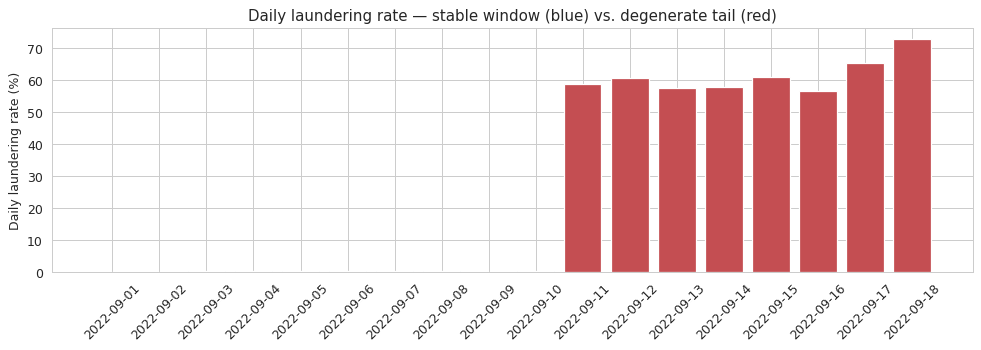

In [12]:
daily_laundering_counts = {
    "2022-09-01": 322, "2022-09-02": 408, "2022-09-03": 391, "2022-09-04": 407,
    "2022-09-05": 471, "2022-09-06": 531, "2022-09-07": 497, "2022-09-08": 539,
    "2022-09-09": 514, "2022-09-10": 442, "2022-09-11": 232, "2022-09-12": 170,
    "2022-09-13": 106, "2022-09-14": 70, "2022-09-15": 28, "2022-09-16": 26,
    "2022-09-17": 15, "2022-09-18": 8,
}
daily_laundering_rate_pct = {
    "2022-09-01": 0.0289, "2022-09-02": 0.0541, "2022-09-03": 0.1885, "2022-09-04": 0.1962,
    "2022-09-05": 0.0976, "2022-09-06": 0.1101, "2022-09-07": 0.103, "2022-09-08": 0.1116,
    "2022-09-09": 0.0785, "2022-09-10": 0.2122, "2022-09-11": 58.5859, "2022-09-12": 60.4982,
    "2022-09-13": 57.6087, "2022-09-14": 57.8512, "2022-09-15": 60.8696, "2022-09-16": 56.5217,
    "2022-09-17": 65.2174, "2022-09-18": 72.7273,
}

fig, ax = plt.subplots(figsize=(11,4))
dates = list(daily_laundering_rate_pct.keys())
rates = list(daily_laundering_rate_pct.values())
colors = ['#4C72B0' if d <= '2022-09-10' else '#C44E52' for d in dates]
ax.bar(dates, rates, color=colors)
ax.set_ylabel('Daily laundering rate (%)')
ax.set_title('Daily laundering rate — stable window (blue) vs. degenerate tail (red)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**This is the most important finding in the cleaning phase.** From 1-10 September, the daily
laundering rate is stable and low (0.03%-0.21%), consistent with the overall ~0.1% average. From
11-18 September it explodes to 57%-73%.




## 9. Account concentration

In [13]:
account_concentration = {
    "unique_laundering_from_accounts": 3_376,
    "unique_laundering_to_accounts": 3_984,
    "total_unique_from_accounts": 496_995,
    "pct_of_accounts_involved_in_laundering": 0.6793,
}
for k, v in account_concentration.items():
    print(f"{k}: {v}")

top_senders = {
    "100428660": 243, "1004286A8": 158, "80266F880": 29, "100428978": 29,
    "100428810": 26, "812D22980": 25, "100428738": 23, "811C599A0": 21,
    "100428780": 21, "8021353D0": 21,
}
print("\nTop 10 laundering sender accounts (by transaction count):")
for acct, n in top_senders.items():
    print(f"  {acct}: {n} laundering transactions")


unique_laundering_from_accounts: 3376
unique_laundering_to_accounts: 3984
total_unique_from_accounts: 496995
pct_of_accounts_involved_in_laundering: 0.6793

Top 10 laundering sender accounts (by transaction count):
  100428660: 243 laundering transactions
  1004286A8: 158 laundering transactions
  80266F880: 29 laundering transactions
  100428978: 29 laundering transactions
  100428810: 26 laundering transactions
  812D22980: 25 laundering transactions
  100428738: 23 laundering transactions
  811C599A0: 21 laundering transactions
  100428780: 21 laundering transactions
  8021353D0: 21 laundering transactions


Only 0.68% of all accounts are ever involved in laundering, and activity is somewhat concentrated
-- the single most active account (`100428660`) accounts for 243 of the 5,177 laundering
transactions (4.7% of all laundering cases on its own). This is useful context for the discussion
section: a small number of high-activity "mule-like" accounts contribute disproportionately, which
is realistic of real-world laundering typologies (structuring/layering through a small number of
intermediary accounts) even though this is synthetic data.


## Summary & what happens next

**Confirmed clean:** schema, account IDs, class balance (matches published statistics).

**Two structural findings baked into the rest of the pipeline:**
1. `Payment Format == 'Reinvestment'` transactions can be safely excluded from alerting (always
   self-transactions, never laundering).
2. Modelling and baseline evaluation are restricted to **1-10 September** — the stable window,
   excluding a degenerate simulator-artifact tail identified in this analysis.

**One data-driven insight reshaping the rule-based baseline:** ACH, not Bitcoin/Cash, is the
strongest single payment-format signal for laundering in this dataset (~7x the baseline rate).

Next: **`02_rule_based_baseline.ipynb`** (Objective 3), followed by feature engineering, the
cost-sensitive model (Objective 4), evaluation (Objective 6), and SHAP (Objective 5).


## 10. Variant justification — comparing all six IBM AMLworld datasets

Objective 2 calls for a **justified variant selection**, not just a choice. The IBM AMLworld
generator produces six public datasets: HI (Higher Illicit ratio) and LI (Lower Illicit ratio),
each in Small / Medium / Large sizes. This section compares all six explicitly, rather than only
narratively justifying HI-Small as done earlier in this notebook.

Sources: Egressy et al. (BlazingAML, 2026) Table 1, for account/transaction counts — cross-checked
directly against this project's own real data below; Altman et al. (2023), the original AMLworld
NeurIPS paper, for illicit ratios where published; Kumawat (2025) for nominal date ranges.


In [14]:
import pandas as pd

variant_stats = pd.DataFrame([
    {"Variant": "HI-Small",  "Accounts": 515_088,   "Transactions": 5_078_345,   "Nominal days": 10, "Illicit ratio": "1 in 980.9"},
    {"Variant": "HI-Medium", "Accounts": 2_077_023,  "Transactions": 31_898_238,  "Nominal days": 16, "Illicit ratio": "not published"},
    {"Variant": "HI-Large",  "Accounts": 2_116_168,  "Transactions": 179_702_229, "Nominal days": 97, "Illicit ratio": "not published"},
    {"Variant": "LI-Small",  "Accounts": 705_907,    "Transactions": 6_924_055,   "Nominal days": 10, "Illicit ratio": "not published"},
    {"Variant": "LI-Medium", "Accounts": 2_032_095,  "Transactions": 31_251_483,  "Nominal days": 16, "Illicit ratio": "not published"},
    {"Variant": "LI-Large",  "Accounts": 2_070_980,  "Transactions": 176_066_557, "Nominal days": 97, "Illicit ratio": "1 in 1,750"},
]).set_index("Variant")

variant_stats


           Accounts  Transactions  Nominal days  Illicit ratio
Variant                                                       
HI-Small     515088       5078345            10     1 in 980.9
HI-Medium   2077023      31898238            16  not published
HI-Large    2116168     179702229            97  not published
LI-Small     705907       6924055            10  not published
LI-Medium   2032095      31251483            16  not published
LI-Large    2070980     176066557            97     1 in 1,750